# DecodeLabs Data Science — Project 3
## Unsupervised Learning (Customer Segmentation)

**Workflow:** Preprocessing → PCA → K-Means → Elbow Method → Silhouette Score → Cluster Profiling → Business Personas

This notebook uses the original Course Dataset and does **not** use `OrderStatus` as a prediction target, because Project 3 is an unsupervised-learning task.


# 1. Project Setup and Imports

In [ ]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")


# 2. Project Paths

In [2]:
PROJECT_DIR = Path.cwd()

DATA_PATH = PROJECT_DIR / "Dataset for Data Analytics - Sheet1.csv"

# Results will be saved in a new 'outputs' folder beside the notebook.
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("DECODELABS PROJECT 3 - UNSUPERVISED LEARNING")
print("=" * 70)
print("Working directory:", PROJECT_DIR)
print("Dataset:", DATA_PATH)
print("Output folder:", OUTPUT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Make sure 'Dataset for Data Analytics - Sheet1.csv' "
        "is in the same folder as this notebook."
    )


DECODELABS PROJECT 3 - UNSUPERVISED LEARNING
Working directory: c:\Users\harsh\OneDrive\Desktop\DecodeLabs_Internship\Project_3
Dataset: c:\Users\harsh\OneDrive\Desktop\DecodeLabs_Internship\Project_3\Dataset for Data Analytics - Sheet1.csv
Output folder: c:\Users\harsh\OneDrive\Desktop\DecodeLabs_Internship\Project_3\outputs


# 3. Load the Raw Course Dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Dataset shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Data types:


OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object


Missing values:


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


Duplicate rows: 0


# 4. Cleaning and Feature Engineering

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Missing values after cleaning:")
display(df.isnull().sum())


Missing values after cleaning:


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Year               0
Month              0
Day                0
DayOfWeek          0
dtype: int64

# 5. Feature Selection

In [5]:
# Project 3 is unsupervised, so OrderStatus is NOT a target.
# Identifier/high-cardinality fields are excluded.

drop_columns = [
    "OrderID",
    "CustomerID",
    "ShippingAddress",
    "TrackingNumber",
    "OrderStatus",
    "Date",
]

df_cluster = df.drop(columns=drop_columns).copy()

numeric_features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
]

categorical_features = [
    "Product",
    "PaymentMethod",
    "CouponCode",
    "ReferralSource",
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nClustering dataset shape:", df_cluster.shape)


Numerical features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'Year', 'Month', 'Day', 'DayOfWeek']

Categorical features:
['Product', 'PaymentMethod', 'CouponCode', 'ReferralSource']

Clustering dataset shape: (1200, 12)


# 6. Standardization and One-Hot Encoding

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features,
        ),
    ]
)

X_processed = preprocessor.fit_transform(df_cluster)
feature_names = preprocessor.get_feature_names_out()

X_processed = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=df.index,
)

print("Processed feature matrix shape:", X_processed.shape)

if X_processed.shape[1] >= 20:
    print("PASS: 20+ dimensions achieved after preprocessing.")
else:
    print("WARNING: Fewer than 20 dimensions.")


Processed feature matrix shape: (1200, 29)
PASS: 20+ dimensions achieved after preprocessing.


# 7. PCA - 95% Variance Analysis

Components required for at least 95% variance: 21


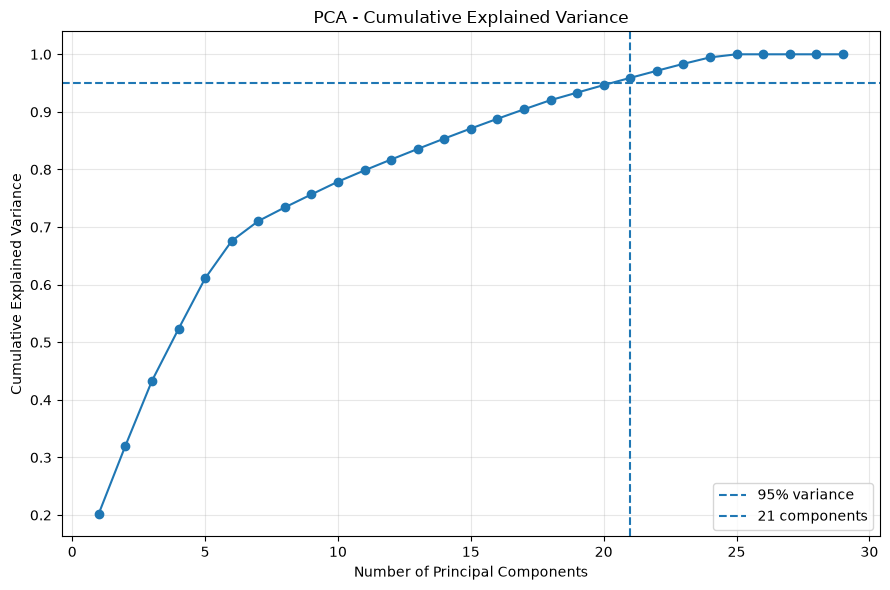

In [7]:
pca_full = PCA()
pca_full.fit(X_processed)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components required for at least 95% variance:",
    components_95
)

plt.figure(figsize=(9, 6))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
)
plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance"
)
plt.axvline(
    components_95,
    linestyle="--",
    label=f"{components_95} components"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "01_pca_cumulative_variance.png",
    dpi=300
)
plt.show()


# 8. PCA to 2 Dimensions

PCA shape: (1200, 2)
Explained variance: [0.20263983 0.11758652]
Total variance retained: 0.32022635341991756


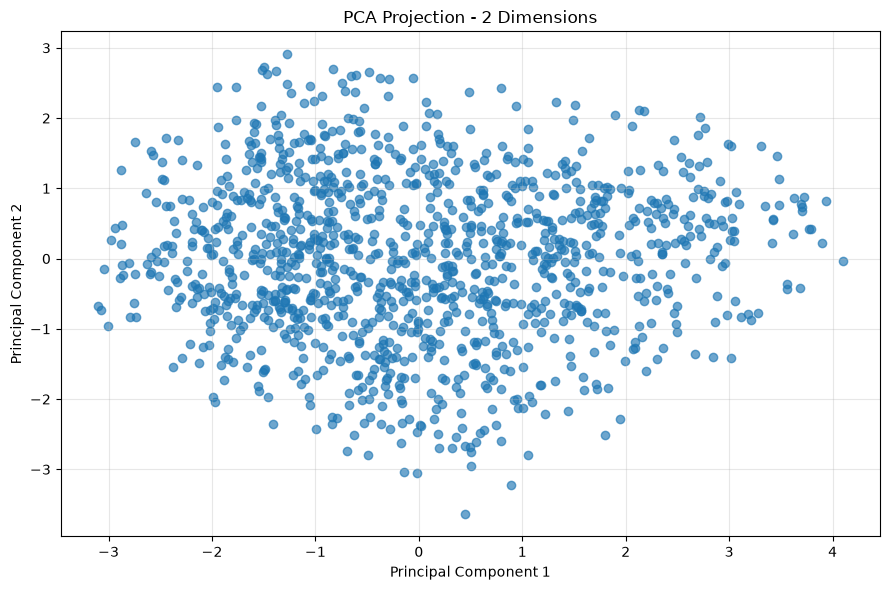

In [8]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df.index,
)

print("PCA shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)
print(
    "Total variance retained:",
    pca.explained_variance_ratio_.sum()
)

plt.figure(figsize=(9, 6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.65
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection - 2 Dimensions")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "02_pca_2d_projection.png",
    dpi=300
)
plt.show()


# 9. Elbow Method

,K,WCSS
0,2,2416.107481
1,3,1590.014750
2,4,1192.667697
3,5,969.711868
4,6,833.319202
5,7,716.178689
6,8,625.651317
7,9,560.121052
8,10,504.432156


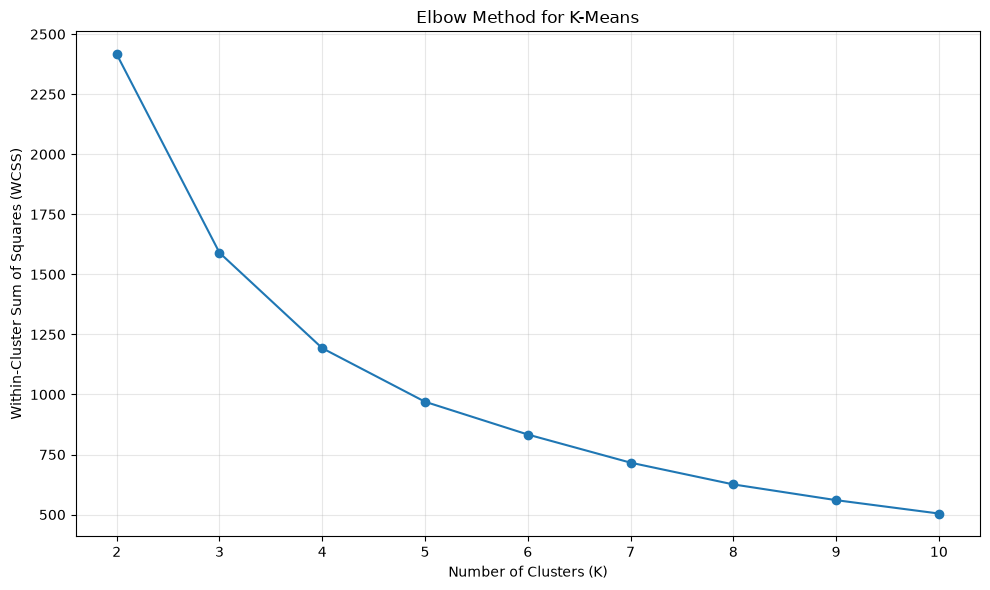

In [9]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_pca)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "WCSS": inertias,
})

display(elbow_results)

plt.figure(figsize=(10, 6))
plt.plot(
    elbow_results["K"],
    elbow_results["WCSS"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Method for K-Means")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "03_elbow_method.png",
    dpi=300
)
plt.show()


# 10. Silhouette Scores

,K,Silhouette Score
0,2,0.389926
1,3,0.381521
2,4,0.371980
3,5,0.360047
4,6,0.354898
5,7,0.349148
6,8,0.343975
7,9,0.345195
8,10,0.350377


Highest silhouette score: K=2, score=0.3899


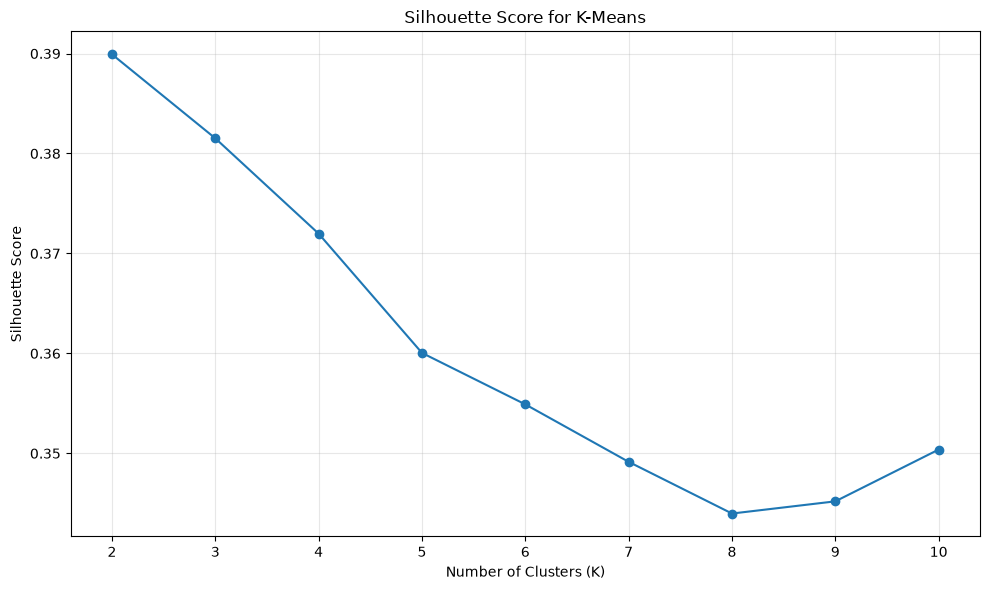

In [10]:
silhouette_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    silhouette_results.append({
        "K": k,
        "Silhouette Score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)

display(silhouette_df)

best_k_by_silhouette = int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "K"
    ]
)

print(
    f"Highest silhouette score: "
    f"K={best_k_by_silhouette}, "
    f"score={silhouette_df['Silhouette Score'].max():.4f}"
)

plt.figure(figsize=(10, 6))
plt.plot(
    silhouette_df["K"],
    silhouette_df["Silhouette Score"],
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "04_silhouette_scores.png",
    dpi=300
)
plt.show()


# 11. Final K-Means Model

In [11]:
# Based on the current analysis:
# K=2 has the highest silhouette score (0.3899).
# The elbow curve has its strongest reductions at the lower K values.
# Therefore K=2 is used for the final model.

FINAL_K = 2

final_kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_pca)

final_silhouette = silhouette_score(
    X_pca,
    cluster_labels
)

df_result = df.copy()
df_result["Cluster"] = cluster_labels

pca_result = pca_df.copy()
pca_result["Cluster"] = cluster_labels

print("Final K:", FINAL_K)
print(f"Final silhouette score: {final_silhouette:.4f}")

print("\nCluster sizes:")
display(
    df_result["Cluster"]
    .value_counts()
    .sort_index()
)


Final K: 2
Final silhouette score: 0.3899

Cluster sizes:


Cluster
0    522
1    678
Name: count, dtype: int64

# 12. Final Cluster Visualization

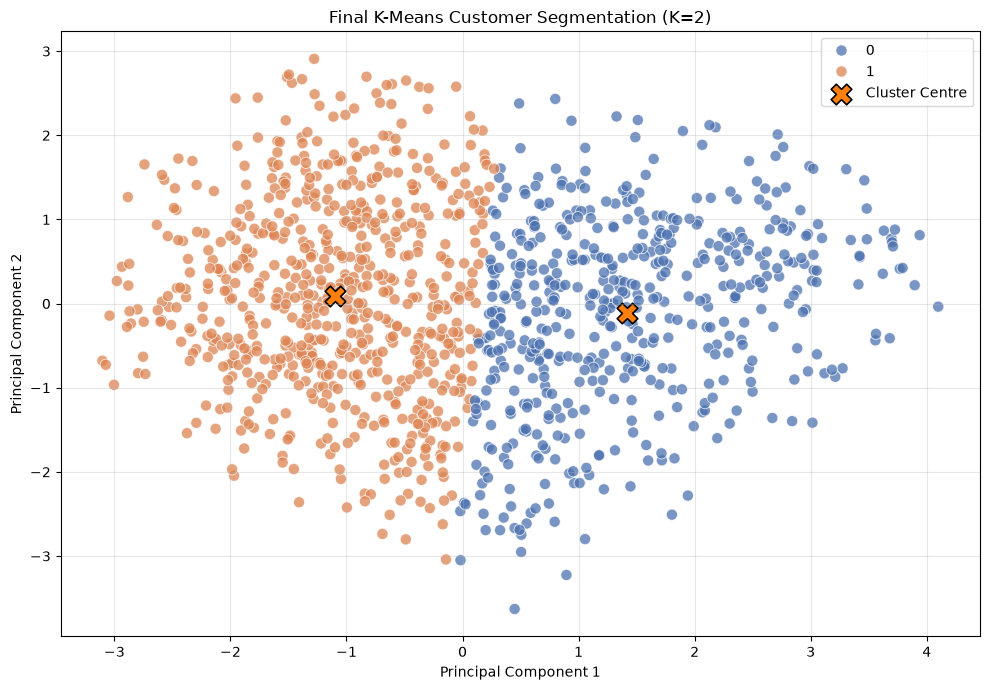

In [12]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_result,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="deep",
    s=65,
    alpha=0.75
)

centres = final_kmeans.cluster_centers_

plt.scatter(
    centres[:, 0],
    centres[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
    linewidth=1.2,
    label="Cluster Centre"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Final K-Means Customer Segmentation (K=2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "05_final_kmeans_clusters.png",
    dpi=300
)
plt.show()


# 13. Cluster Size Profile

In [13]:
cluster_size_profile = pd.concat(
    [
        df_result["Cluster"]
        .value_counts()
        .sort_index()
        .rename("Count"),

        (
            df_result["Cluster"]
            .value_counts(normalize=True)
            .sort_index()
            .mul(100)
            .rename("Percentage")
        ),
    ],
    axis=1,
)

display(cluster_size_profile)


,Count,Percentage
Cluster,,
0,522,43.5
1,678,56.5


# 14. Numerical Cluster Profiling

In [14]:
numeric_profile = (
    df_result
    .groupby("Cluster")[numeric_features]
    .mean()
    .round(2)
)

numeric_median_profile = (
    df_result
    .groupby("Cluster")[numeric_features]
    .median()
    .round(2)
)

print("Mean profile:")
display(numeric_profile)

print("Median profile:")
display(numeric_median_profile)


Mean profile:


,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,DayOfWeek
Cluster,,,,,,,,
0,4.12,435.53,7.05,1740.75,2023.70,5.97,16.66,3.03
1,2.04,295.50,4.28,525.21,2023.82,6.01,15.43,3.06


Median profile:


,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,DayOfWeek
Cluster,,,,,,,,
0,4.0,463.42,7.0,1709.66,2024.0,6.0,17.0,3.0
1,2.0,266.29,4.0,474.10,2024.0,6.0,15.0,3.0


# 15. Categorical Cluster Profiling

In [15]:
def most_common_category(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else "N/A"

categorical_profile = pd.DataFrame({
    feature: df_result
        .groupby("Cluster")[feature]
        .agg(most_common_category)
    for feature in categorical_features
})

display(categorical_profile)

for feature in categorical_features:
    distribution = (
        pd.crosstab(
            df_result["Cluster"],
            df_result[feature],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )

    print(f"\n{feature} distribution by cluster (%):")
    display(distribution)

    safe_name = feature.replace(" ", "_").replace("/", "_")

    distribution.to_csv(
        OUTPUT_DIR / f"cluster_distribution_{safe_name}.csv"
    )


,Product,PaymentMethod,CouponCode,ReferralSource
Cluster,,,,
0,Chair,Credit Card,FREESHIP,Instagram
1,Tablet,Online,FREESHIP,Instagram



Product distribution by cluster (%):


Product,Chair,Desk,Laptop,Monitor,Phone,Printer,Tablet
Cluster,,,,,,,
0,17.62,14.75,14.94,13.98,9.77,15.13,13.79
1,12.68,13.72,14.01,13.27,15.49,15.04,15.78



PaymentMethod distribution by cluster (%):


PaymentMethod,Cash,Credit Card,Debit Card,Gift Card,Online
Cluster,,,,,
0,21.65,22.22,18.97,19.35,17.82
1,19.62,17.40,19.62,19.03,24.34



CouponCode distribution by cluster (%):


CouponCode,FREESHIP,NoCoupon,SAVE10,WINTER15
Cluster,,,,
0,25.86,25.10,23.75,25.29
1,26.25,26.25,23.89,23.60



ReferralSource distribution by cluster (%):


ReferralSource,Email,Facebook,Google,Instagram,Referral
Cluster,,,,,
0,20.88,20.11,19.92,21.65,17.43
1,20.80,18.14,20.21,21.53,19.32


# 16. Relative Cluster Differences

In [16]:
overall_means = df_result[numeric_features].mean()

relative_profile = (
    numeric_profile
    .div(overall_means, axis=1)
    .sub(1)
    .mul(100)
    .round(2)
)

print("Cluster difference from overall mean (%):")
display(relative_profile)


Cluster difference from overall mean (%):


,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,DayOfWeek
Cluster,,,,,,,,
0,39.86,22.20,28.53,65.16,-0.0,-0.42,4.33,-0.68
1,-30.75,-17.09,-21.97,-50.17,0.0,0.25,-3.38,0.30


# 17. Business Personas

In [17]:
# Descriptive personas derived from observed cluster characteristics.
# These are not target labels or predictions.

overall_total_price = df_result["TotalPrice"].mean()
overall_items = df_result["ItemsInCart"].mean()
overall_quantity = df_result["Quantity"].mean()
overall_unit_price = df_result["UnitPrice"].mean()

persona_rows = []

for cluster in sorted(df_result["Cluster"].unique()):

    cluster_data = df_result[
        df_result["Cluster"] == cluster
    ]

    total_price = cluster_data["TotalPrice"].mean()
    items = cluster_data["ItemsInCart"].mean()
    quantity = cluster_data["Quantity"].mean()
    unit_price = cluster_data["UnitPrice"].mean()

    common_product = most_common_category(
        cluster_data["Product"]
    )
    common_payment = most_common_category(
        cluster_data["PaymentMethod"]
    )
    common_coupon = most_common_category(
        cluster_data["CouponCode"]
    )
    common_referral = most_common_category(
        cluster_data["ReferralSource"]
    )

    characteristics = []

    characteristics.append(
        "higher average order value"
        if total_price >= overall_total_price
        else "lower average order value"
    )

    characteristics.append(
        "larger basket size"
        if items >= overall_items
        else "smaller basket size"
    )

    characteristics.append(
        "higher average quantity"
        if quantity >= overall_quantity
        else "lower average quantity"
    )

    characteristics.append(
        "higher-priced products"
        if unit_price >= overall_unit_price
        else "lower-priced products"
    )

    if (
        total_price >= overall_total_price
        and items >= overall_items
    ):
        persona_name = "Higher-Value / Larger-Basket Profile"
    elif (
        total_price < overall_total_price
        and items < overall_items
    ):
        persona_name = "Lower-Value / Smaller-Basket Profile"
    elif total_price >= overall_total_price:
        persona_name = "Higher-Value Profile"
    else:
        persona_name = "Lower-Value Profile"

    persona_rows.append({
        "Cluster": cluster,
        "Persona": persona_name,
        "Cluster Size": len(cluster_data),
        "Cluster Percentage": round(
            len(cluster_data) / len(df_result) * 100,
            2
        ),
        "Average TotalPrice": round(total_price, 2),
        "Average ItemsInCart": round(items, 2),
        "Average Quantity": round(quantity, 2),
        "Average UnitPrice": round(unit_price, 2),
        "Common Product": common_product,
        "Common Payment Method": common_payment,
        "Common Coupon": common_coupon,
        "Common Referral Source": common_referral,
        "Key Characteristics": "; ".join(characteristics),
    })

persona_df = pd.DataFrame(persona_rows)

display(persona_df)


,Cluster,Persona,Cluster Size,Cluster Percentage,Average TotalPrice,Average ItemsInCart,Average Quantity,Average UnitPrice,Common Product,Common Payment Method,Common Coupon,Common Referral Source,Key Characteristics
0,0,Higher-Value / Larger-Basket Profile,522,43.5,1740.75,7.05,4.12,435.53,Chair,Credit Card,FREESHIP,Instagram,higher average order value; larger basket size...
1,1,Lower-Value / Smaller-Basket Profile,678,56.5,525.21,4.28,2.04,295.50,Tablet,Online,FREESHIP,Instagram,lower average order value; smaller basket size...


# 18. Save Results

The generated CSV files and plots are saved automatically in:
`Project_3/outputs/`


In [18]:
df_result.to_csv(
    OUTPUT_DIR / "project3_clustered_dataset.csv",
    index=False
)

pca_result.to_csv(
    OUTPUT_DIR / "project3_pca_clusters.csv",
    index=False
)

cluster_size_profile.to_csv(
    OUTPUT_DIR / "project3_cluster_sizes.csv"
)

numeric_profile.to_csv(
    OUTPUT_DIR / "project3_numeric_cluster_profile.csv"
)

numeric_median_profile.to_csv(
    OUTPUT_DIR / "project3_numeric_cluster_median_profile.csv"
)

categorical_profile.to_csv(
    OUTPUT_DIR / "project3_categorical_cluster_profile.csv"
)

elbow_results.to_csv(
    OUTPUT_DIR / "project3_elbow_results.csv",
    index=False
)

silhouette_df.to_csv(
    OUTPUT_DIR / "project3_silhouette_results.csv",
    index=False
)

persona_df.to_csv(
    OUTPUT_DIR / "project3_business_personas.csv",
    index=False
)

print("All results saved to:", OUTPUT_DIR)


All results saved to: c:\Users\harsh\OneDrive\Desktop\DecodeLabs_Internship\Project_3\outputs


# 19. Final Project Summary

In [19]:
print("=" * 70)
print("PROJECT 3 FINAL SUMMARY")
print("=" * 70)

print("Original dataset shape:", df.shape)
print("Processed feature matrix shape:", X_processed.shape)
print("Components for 95% variance:", components_95)

print(
    "2D PCA variance retained:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

print("Selected K:", FINAL_K)
print(f"Final silhouette score: {final_silhouette:.4f}")

print("\nCluster sizes:")
display(cluster_size_profile)

print("\nBusiness personas:")
display(
    persona_df[
        [
            "Cluster",
            "Persona",
            "Cluster Size",
            "Cluster Percentage",
            "Key Characteristics"
        ]
    ]
)

print("\nProject 3 completed successfully.")


PROJECT 3 FINAL SUMMARY
Original dataset shape: (1200, 18)
Processed feature matrix shape: (1200, 29)
Components for 95% variance: 21
2D PCA variance retained: 32.02 %
Selected K: 2
Final silhouette score: 0.3899

Cluster sizes:


,Count,Percentage
Cluster,,
0,522,43.5
1,678,56.5



Business personas:


,Cluster,Persona,Cluster Size,Cluster Percentage,Key Characteristics
0,0,Higher-Value / Larger-Basket Profile,522,43.5,higher average order value; larger basket size...
1,1,Lower-Value / Smaller-Basket Profile,678,56.5,lower average order value; smaller basket size...



Project 3 completed successfully.
